<a href="https://colab.research.google.com/github/HusainAhmadKhan/Karachi_Air_Pollution_Prediction/blob/main/Karachi_Air_Pollution_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Name: Husain Ahmad Khan  Roll No.: 23
# Name: Habib ur Rehman Khan  Roll No.: 19
# Name: Malik Hamza Ali Awan  Roll No.: 29
# Name: Moaz Amir  Roll No.: 31

**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [3]:
df = pd.read_excel("Karachi Aga khan University Air Quality.xlsx")
df.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,4837113,Aga khan University Main Campus,pm1,40.0,µg/m³,2026-03-01T01:00:00Z,2026-03-01T06:00:00+05:00,Asia/Karachi,24.892402,67.074663,NaN,NaN,NaN,The Urban Unit,AirGradient
1,4837113,Aga khan University Main Campus,pm1,58.4,µg/m³,2026-03-01T02:00:00Z,2026-03-01T07:00:00+05:00,Asia/Karachi,24.892402,67.074663,NaN,NaN,NaN,The Urban Unit,AirGradient
2,4837113,Aga khan University Main Campus,pm1,70.1,µg/m³,2026-03-01T03:00:00Z,2026-03-01T08:00:00+05:00,Asia/Karachi,24.892402,67.074663,NaN,NaN,NaN,The Urban Unit,AirGradient
3,4837113,Aga khan University Main Campus,pm1,52.8,µg/m³,2026-03-01T04:00:00Z,2026-03-01T09:00:00+05:00,Asia/Karachi,24.892402,67.074663,NaN,NaN,NaN,The Urban Unit,AirGradient
4,4837113,Aga khan University Main Campus,pm1,35.9,µg/m³,2026-03-01T05:00:00Z,2026-03-01T10:00:00+05:00,Asia/Karachi,24.892402,67.074663,NaN,NaN,NaN,The Urban Unit,AirGradient


**Understand Data**

In [4]:
print(df['parameter'].unique())

['pm1' 'pm25' 'relativehumidity' 'temperature' 'um003']


**Convert Data (MOST IMPORTANT STEP)**

In [5]:
df_pivot = df.pivot_table(
    index='datetimeLocal',
    columns='parameter',
    values='value'
).reset_index()

**Clean Column Names**

In [6]:
df_pivot.columns.name = None

df_pivot.rename(columns={
    'pm25': 'PM25',
    'pm1': 'PM1',
    'relativehumidity': 'Humidity',
    'temperature': 'Temperature',
    'um003': 'UM003'
}, inplace=True)

df_pivot.head()

,datetimeLocal,PM1,PM25,Humidity,Temperature,UM003
0,2026-03-01T06:00:00+05:00,40.0,65.6,62.0,23.5,2992.0
1,2026-03-01T07:00:00+05:00,58.4,98.0,61.0,23.8,4302.0
2,2026-03-01T08:00:00+05:00,70.1,122.5,62.0,23.1,5212.0
3,2026-03-01T09:00:00+05:00,52.8,89.4,61.0,23.7,3910.0
4,2026-03-01T10:00:00+05:00,35.9,58.3,57.0,24.8,2626.0


**Convert Time Feature**

In [7]:
df_pivot['datetimeLocal'] = pd.to_datetime(df_pivot['datetimeLocal'])

df_pivot['hour'] = df_pivot['datetimeLocal'].dt.hour
df_pivot['day'] = df_pivot['datetimeLocal'].dt.day
df_pivot['month'] = df_pivot['datetimeLocal'].dt.month

df_pivot.head()

,datetimeLocal,PM1,PM25,Humidity,Temperature,UM003,hour,day,month
0,2026-03-01 06:00:00+05:00,40.0,65.6,62.0,23.5,2992.0,6,1,3
1,2026-03-01 07:00:00+05:00,58.4,98.0,61.0,23.8,4302.0,7,1,3
2,2026-03-01 08:00:00+05:00,70.1,122.5,62.0,23.1,5212.0,8,1,3
3,2026-03-01 09:00:00+05:00,52.8,89.4,61.0,23.7,3910.0,9,1,3
4,2026-03-01 10:00:00+05:00,35.9,58.3,57.0,24.8,2626.0,10,1,3


**Handle Missing Values**

In [8]:
df_pivot.fillna(df_pivot.mean(numeric_only=True), inplace=True)

**Correlation (IMPORTANT)**

In [9]:
df_pivot.corr()

,datetimeLocal,PM1,PM25,Humidity,Temperature,UM003,hour,day,month
datetimeLocal,1.000000,-0.421227,-0.441479,0.113809,-0.087623,-0.431588,0.005073,0.183073,0.761622
PM1,-0.421227,1.000000,0.991664,0.297893,-0.232148,0.979868,-0.262784,-0.418429,-0.090379
PM25,-0.441479,0.991664,1.000000,0.301459,-0.234363,0.985664,-0.262650,-0.390239,-0.126830
Humidity,0.113809,0.297893,0.301459,1.000000,-0.809230,0.298519,-0.320864,0.016844,0.096085
Temperature,-0.087623,-0.232148,-0.234363,-0.809230,1.000000,-0.262606,0.302634,0.020912,-0.097479
UM003,-0.431588,0.979868,0.985664,0.298519,-0.262606,1.000000,-0.272456,-0.385156,-0.121246
hour,0.005073,-0.262784,-0.262650,-0.320864,0.302634,-0.272456,1.000000,-0.009987,-0.010020
day,0.183073,-0.418429,-0.390239,0.016844,0.020912,-0.385156,-0.009987,1.000000,-0.497300
month,0.761622,-0.090379,-0.126830,0.096085,-0.097479,-0.121246,-0.010020,-0.497300,1.000000


**Heatmap (EDA)**

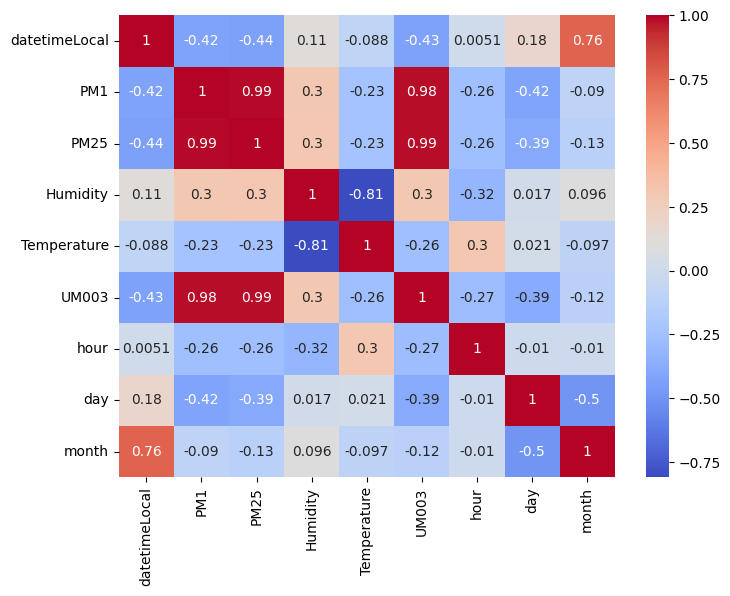

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df_pivot.corr(), annot=True, cmap="coolwarm")
plt.show()

**Drop Weak Feature**

In [11]:
df_pivot.drop(columns=['UM003', 'month'], inplace=True)

**Feature Engineering**

In [12]:
df_pivot['Pollution_Index'] = df_pivot['PM25'] + df_pivot['PM1']
df_pivot['Temp_Humidity_Ratio'] = df_pivot['Temperature'] / (df_pivot['Humidity'] + 1)

**Define Features & Target**

In [13]:
X = df_pivot.drop(['datetimeLocal', 'PM25'], axis=1)
y = df_pivot['PM25']

**Train-Test Split**

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**MODEL 1 — Linear Regression**

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**MODEL 2 — Decision Tree**

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

**MODEL 3 — Random Forest**

In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**Evaluation**

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(name, y_test, y_pred):
    print(name)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("----------------------")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)

Linear Regression
R2 Score: 1.0
MSE: 1.475021981343563e-28
----------------------
Decision Tree
R2 Score: 0.9967629514662866
MSE: 1.41435
----------------------
Random Forest
R2 Score: 0.998119980779917
MSE: 0.8214288899999925
----------------------


**Removed Leakage**

In [19]:
df_pivot.drop(columns=['Pollution_Index'], inplace=True)

In [20]:
X = df_pivot.drop(['datetimeLocal', 'PM25'], axis=1)
y = df_pivot['PM25']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [23]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(name, y_test, y_pred):
    print(name)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("----------------------")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)

Linear Regression
R2 Score: 0.9804248810058472
MSE: 8.552874404270888
----------------------
Decision Tree
R2 Score: 0.9853583832964085
MSE: 6.3973
----------------------
Random Forest
R2 Score: 0.9906278043123655
MSE: 4.094954040000011
----------------------


**BEST MODEL CHECK**
The one with highest R² is best (Random Forest)

**Graph**

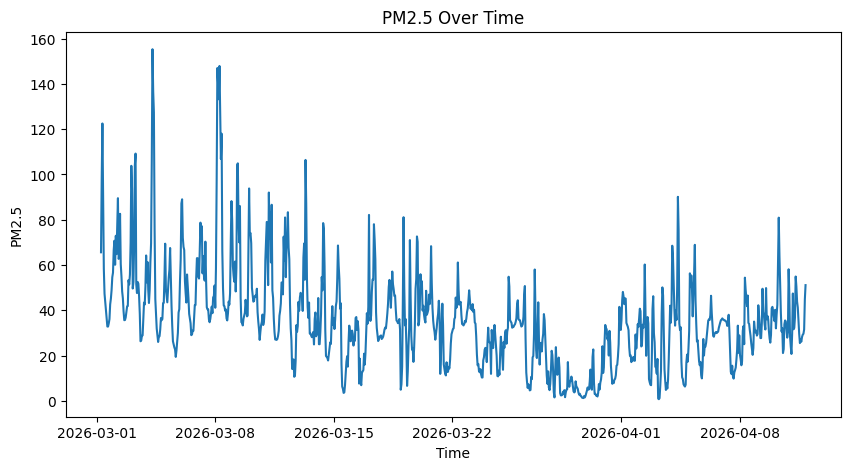

In [26]:
plt.figure(figsize=(10,5))
plt.plot(df_pivot['datetimeLocal'], df_pivot['PM25'])
plt.title("PM2.5 Over Time")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

**Classification**

In [27]:
def categorize(pm):
    if pm < 50:
        return "Good"
    elif pm < 100:
        return "Moderate"
    else:
        return "Hazardous"

df_pivot['Category'] = df_pivot['PM25'].apply(categorize)

In [28]:
df_pivot.head()

,datetimeLocal,PM1,PM25,Humidity,Temperature,hour,day,Temp_Humidity_Ratio,Category
0,2026-03-01 06:00:00+05:00,40.0,65.6,62.0,23.5,6,1,0.373016,Moderate
1,2026-03-01 07:00:00+05:00,58.4,98.0,61.0,23.8,7,1,0.383871,Moderate
2,2026-03-01 08:00:00+05:00,70.1,122.5,62.0,23.1,8,1,0.366667,Hazardous
3,2026-03-01 09:00:00+05:00,52.8,89.4,61.0,23.7,9,1,0.382258,Moderate
4,2026-03-01 10:00:00+05:00,35.9,58.3,57.0,24.8,10,1,0.427586,Moderate


**User Interface**

In [ ]:
import ipywidgets as widgets
from IPython.display import display

pm1 = widgets.FloatText(description="PM1")
temp = widgets.FloatText(description="Temp")
humidity = widgets.FloatText(description="Humidity")
hour = widgets.IntText(description="Hour")
day = widgets.IntText(description="Day")

button = widgets.Button(description="Predict PM2.5")

def predict(b):
    temp_humidity_ratio = temp.value / (humidity.value + 1)

    input_df = pd.DataFrame([{
        'PM1': pm1.value,
        'Humidity': humidity.value,
        'Temperature': temp.value,
        'hour': hour.value,
        'day': day.value,
        'Temp_Humidity_Ratio': temp_humidity_ratio
    }])

    result = rf.predict(input_df)
    print("Predicted PM2.5:", result[0])

button.on_click(predict)

display(pm1, temp, humidity, hour, day, button)